In [2]:
pip install numpy pandas matplotlib


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip list

Package                 Version
----------------------- -----------
appnope                 0.1.4
asttokens               3.0.1
comm                    0.2.3
contourpy               1.3.3
cycler                  0.12.1
debugpy                 1.8.20
decorator               5.2.1
executing               2.2.1
fonttools               4.62.1
ipykernel               7.2.0
ipython                 9.12.0
ipython_pygments_lexers 1.1.1
jedi                    0.19.2
jupyter_client          8.8.0
jupyter_core            5.9.1
kiwisolver              1.5.0
matplotlib              3.10.8
matplotlib-inline       0.2.1
nest-asyncio            1.6.0
numpy                   2.4.4
packaging               26.0
pandas                  3.0.2
parso                   0.8.6
pexpect                 4.9.0
pillow                  12.2.0
pip                     26.0
platformdirs            4.9.4
prompt_toolkit          3.0.52
psutil                  7.2.2
ptyprocess              0.7.0
pure_eval               0.

In [7]:
pip install scikit-learn

  Using cached scikit_learn-1.8.0-cp314-cp314-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached scipy-1.17.1-cp314-cp314-macosx_14_0_arm64.whl.metadata (62 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.8.0-cp314-cp314-macosx_12_0_arm64.whl (8.1 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached scipy-1.17.1-cp314-cp314-macosx_14_0_arm64.whl (20.3 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn]0m 3/4 [scikit-learn]

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [26]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

df = pd.read_csv('2024_ipl_data.csv');
df.head()


,Id,City,match_type,Date,Man of Match,venue,team 1,team 2,toss_winner,toss_decision,winner,result,run_margin,run_score,over
0,1422119,Chennai,League,22-03-2024,Mustafizur Rahman,"MA Chidambaram Stadium, Chepauk, Chennai",Royal Challengers Bengaluru,Chennai Super Kings,Royal Challengers Bengaluru,bat,Chennai Super Kings,wickets,6,174,20
1,1422120,Mohali,League,23-03-2024,SM Curran,Maharaja Yadavindra Singh International Cricke...,Delhi Capitals,Punjab Kings,Punjab Kings,field,Punjab Kings,wickets,4,175,20
2,1422121,Kolkata,League,23-03-2024,AD Russell,"Eden Gardens, Kolkata",Kolkata Knight Riders,Sunrisers Hyderabad,Sunrisers Hyderabad,field,Kolkata Knight Riders,runs,4,209,20
3,1422122,Jaipur,League,24-03-2024,SV Samson,"Sawai Mansingh Stadium, Jaipur",Rajasthan Royals,Lucknow Super Giants,Rajasthan Royals,bat,Rajasthan Royals,runs,20,194,20
4,1422123,Ahmedabad,League,24-03-2024,B Sai Sudharsan,"Narendra Modi Stadium, Ahmedabad",Gujarat Titans,Mumbai Indians,Mumbai Indians,field,Gujarat Titans,runs,6,169,20


In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Id             71 non-null     int64
 1   City           71 non-null     str  
 2   match_type     71 non-null     str  
 3   Date           71 non-null     str  
 4   Man of Match   71 non-null     str  
 5   venue          71 non-null     str  
 6   team 1         71 non-null     str  
 7   team 2         71 non-null     str  
 8   toss_winner    71 non-null     str  
 9   toss_decision  71 non-null     str  
 10  winner         71 non-null     str  
 11  result         71 non-null     str  
 12  run_margin     71 non-null     int64
 13  run_score      71 non-null     int64
 14  over           71 non-null     int64
dtypes: int64(4), str(11)
memory usage: 8.4 KB


In [30]:
df = df.drop(['Man of Match', 'Date', 'Id'], axis=1)

In [31]:
df['team_1_win'] = (df['winner'] == df['team 1']).astype(int)

In [32]:
df.head()

,City,match_type,venue,team 1,team 2,toss_winner,toss_decision,winner,result,run_margin,run_score,over,team_1_win
0,Chennai,League,"MA Chidambaram Stadium, Chepauk, Chennai",Royal Challengers Bengaluru,Chennai Super Kings,Royal Challengers Bengaluru,bat,Chennai Super Kings,wickets,6,174,20,0
1,Mohali,League,Maharaja Yadavindra Singh International Cricke...,Delhi Capitals,Punjab Kings,Punjab Kings,field,Punjab Kings,wickets,4,175,20,0
2,Kolkata,League,"Eden Gardens, Kolkata",Kolkata Knight Riders,Sunrisers Hyderabad,Sunrisers Hyderabad,field,Kolkata Knight Riders,runs,4,209,20,1
3,Jaipur,League,"Sawai Mansingh Stadium, Jaipur",Rajasthan Royals,Lucknow Super Giants,Rajasthan Royals,bat,Rajasthan Royals,runs,20,194,20,1
4,Ahmedabad,League,"Narendra Modi Stadium, Ahmedabad",Gujarat Titans,Mumbai Indians,Mumbai Indians,field,Gujarat Titans,runs,6,169,20,1


In [33]:
df = pd.get_dummies(df, drop_first=True)

In [34]:
X = df.drop('team_1_win', axis=1)
y = df['team_1_win']

In [52]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [53]:
train_columns = X.columns

In [54]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [55]:
y_pred = model.predict(X_test)

In [56]:
from sklearn.metrics import accuracy_score

print('Acc', accuracy_score(y_pred, y_test))

Acc 0.8


In [72]:
new_match = {
'team 1': 'Royal Challengers Bengaluru',
'team 2': 'Rajasthan Royals',
'venue': 'Dubai International Cricket Stadium',
'city': 'NA',
'toss_winner': 'Rajasthan Royals',
'toss_decision': 'bat'
}

new_df = pd.DataFrame([new_match])

new_df = pd.get_dummies(new_df)

new_df = new_df.reindex(columns=train_columns, fill_value=0)

prediction = model.predict(new_df)
probability = model.predict_proba(new_df)

print("Prediction:", prediction)
print("Win Probability:", probability)

Prediction: [0]
Win Probability: [[0.99851599 0.00148401]]


In [1]:
pip list

Package                 Version
----------------------- -----------
appnope                 0.1.4
asttokens               3.0.1
comm                    0.2.3
contourpy               1.3.3
cycler                  0.12.1
debugpy                 1.8.20
decorator               5.2.1
executing               2.2.1
fonttools               4.62.1
ipykernel               7.2.0
ipython                 9.12.0
ipython_pygments_lexers 1.1.1
jedi                    0.19.2
joblib                  1.5.3
jupyter_client          8.8.0
jupyter_core            5.9.1
kiwisolver              1.5.0
matplotlib              3.10.8
matplotlib-inline       0.2.1
nest-asyncio            1.6.0
numpy                   2.4.4
packaging               26.0
pandas                  3.0.2
parso                   0.8.6
pexpect                 4.9.0
pillow                  12.2.0
pip                     26.0
platformdirs            4.9.4
prompt_toolkit          3.0.52
psutil                  7.2.2
ptyprocess              0.

In [1]:
pip uninstall xgboost -y

Found existing installation: xgboost 3.2.0
Uninstalling xgboost-3.2.0:
  Successfully uninstalled xgboost-3.2.0
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install xgboost

  Using cached xgboost-3.2.0-py3-none-macosx_12_0_arm64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-macosx_12_0_arm64.whl (2.3 MB)

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: /Users/sam/Projects/IPL Predicter/IPLPredicter/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [9]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

df = pd.read_csv('2024_ipl_data.csv');

from sklearn.preprocessing import LabelEncoder


X = df.drop('winner', axis=1)
y = df['winner']


le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05)
model.fit(X_train, y_encoded)

ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:City: str, match_type: str, Date: str, Man of Match: str, venue: str, team 1: str, team 2: str, toss_winner: str, toss_decision: str, result: str

In [ ]:
prediction = model.predict(X_test)          # win/lose
probability = model.predict_proba(X_test)  # probability

In [25]:
# 1. Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# 2. Load dataset
data = pd.read_csv("2024_ipl_data.csv")

# 3. Drop useless columns
data = data.drop(['Date', 'Man of Match'], axis=1)

# 4. Encode target (result)
le = LabelEncoder()
data['winner'] = le.fit_transform(data['winner'])

# 5. Convert categorical features → numeric
data = pd.get_dummies(data, columns=[
    'City', 'match_type', 'venue',
    'team 1', 'team 2',
    'toss_winner', 'toss_decision'
])

# 6. Split features & target
X = data.drop('winner', axis=1)
y = data['winner']

X = pd.get_dummies(X)

# 7. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 8. Train XGBoost model
model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

model.fit(X_train, y_train)

# 9. Predictions
y_pred = model.predict(X_test)

# 10. Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# 11. Predict new match (example)
sample = X_test.iloc[0:1]   # just testing with existing row
pred = model.predict(sample)

# Convert back to team name
print("Predicted winner:", le.inverse_transform(pred))

/Users/sam/Projects/IPL Predicter/IPLPredicter/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [19:59:55] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.5333333333333333
Predicted winner: ['Punjab Kings']


Predicted winner: Mumbai Indians


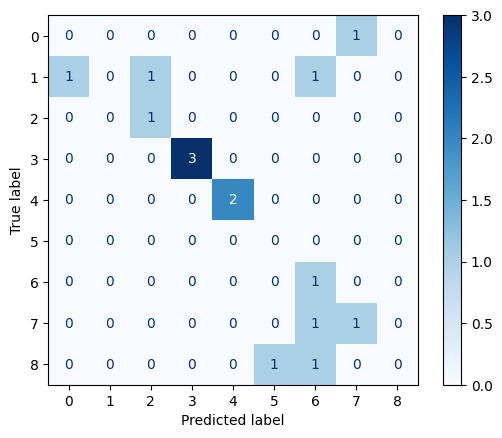

In [30]:
# 10. Create new match input
new_match = pd.DataFrame([{
    'City': 'Bengaluru',
    'match_type': 'League',
    'venue': 'M Chinnaswamy Stadium',
    'team 1': 'Mumbai Indians',
    'team 2': 'Royal Challengers Bengaluru',
    'toss_winner': 'Chennai Super Kings',
    'toss_decision': 'bat'
}])

# 11. Apply same encoding
new_match = pd.get_dummies(new_match)

# 12. Match columns with training data
new_match = new_match.reindex(columns=X.columns, fill_value=0)

# 13. Predict
pred = model.predict(new_match)
prob = model.predict_proba(new_match)

# 14. Output
print("Predicted winner:", le.inverse_transform(pred)[0])
# print("Win probabilities:", prob)

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

confusion_matrix(y_test, y_pred)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [22]:
# 1. Imports
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# 2. Load dataset
data = pd.read_csv("2024_ipl_data.csv")

# 3. Drop unnecessary columns
data = data.drop(['Date', 'Man of Match'], axis=1)

# 4. Create binary target
# 1 = Team1 wins, 0 = Team1 loses
data['result'] = (data['winner'] == data['team 1']).astype(int)

# 5. Features
X = data.drop(['winner', 'result'], axis=1)
y = data['winner']

# 6. Convert categorical → numeric
X = pd.get_dummies(X)

# 7. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 8. Train model
model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

# 9. Accuracy
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))


# =========================
# 🔥 CUSTOM MATCH PREDICTION
# =========================

# 10. Create new match
new_match = pd.DataFrame([{
    'City': 'Mumbai',
    'match_type': 'League',
    'venue': 'Wankhede Stadium',
    'team 1': 'Mumbai Indians',
    'team 2': 'Chennai Super Kings',
    'toss_winner': 'Mumbai Indians',
    'toss_decision': 'bat'
}])

# 11. Apply same encoding
new_match = pd.get_dummies(new_match)

# 12. Match columns
new_match = new_match.reindex(columns=X.columns, fill_value=0)

# 13. Predict
prob = model.predict_proba(new_match)[0]

# 14. Output
team1 = new_match.columns[new_match.columns.str.contains('team 1_')][0].replace('team 1_', '')
team2 = new_match.columns[new_match.columns.str.contains('team 2_')][0].replace('team 2_', '')

print(f"{team1} win probability:", prob[1])
print(f"{team2} win probability:", prob[0])

if prob[1] > prob[0]:
    print("Predicted winner:", team1)
else:
    print("Predicted winner:", team2)

ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0 1 2 3 4 5 6 7 8 9], got ['Chennai Super Kings' 'Delhi Capitals' 'Gujarat Titans'
 'Kolkata Knight Riders' 'Lucknow Super Giants' 'Mumbai Indians'
 'Punjab Kings' 'Rajasthan Royals' 'Royal Challengers Bengaluru'
 'Sunrisers Hyderabad']